# RLAD Noise-Control Experiment: Track A (Clean) vs Track B (Mixed) — Qwen3-0.6B, 150-Step Analysis

This notebook analyzes the results of the Qwen3-0.6B run of the RLAD noise-control experiment, comparing:
- **Track A (clean):** Trained on standard GSM8K data (Completed 150 steps)
- **Track B (mixed):** Trained on GSM8K with prepended trivia facts (Completed 150 steps)

Both tracks use identical hyperparameters and evaluate on the same clean test set. This analysis covers the entire 150 training steps for both models.

All data is fetched directly from WandB and Modal AI artifacts — no external CSV files required.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import seaborn as sns
import wandb
import os

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Fetch histories directly from WandB
PROJECT = "cfw20-stanford-university/rlad-noise-control"
RUN_ID_CLEAN = "kvbep5gl"   # qwen3-0p6b-gsm8k-grpo-clean
RUN_ID_MIXED = "zh9cbjbh"  # qwen3-0p6b-gsm8k-grpo-mixed

api = wandb.Api()
run_a = api.run(f"{PROJECT}/{RUN_ID_CLEAN}")
run_b = api.run(f"{PROJECT}/{RUN_ID_MIXED}")

# Pull full histories as DataFrames
df_a = run_a.history(samples=10000, pandas=True)
df_b = run_b.history(samples=10000, pandas=True)

# Pull summary dicts
summary_a = dict(run_a.summary)
summary_b = dict(run_b.summary)

print(f"Track A (clean):  {run_a.name} ({RUN_ID_CLEAN})")
print(f"Track B (mixed):  {run_b.name} ({RUN_ID_MIXED})")
print()
print(f"Track A: {len(df_a)} rows, steps: {df_a['_step'].min():.0f} - {df_a['_step'].max():.0f}")
print(f"Track B: {len(df_b)} rows, steps: {df_b['_step'].min():.0f} - {df_b['_step'].max():.0f}")

Track A (clean):  qwen3-0p6b-gsm8k-grpo-clean (kvbep5gl)
Track B (mixed):  qwen3-0p6b-gsm8k-grpo-mixed (zh9cbjbh)

Track A: 148 rows, steps: 3 - 150
Track B: 151 rows, steps: 0 - 150


In [22]:
import subprocess

ROLLOUT_DIR = "rollouts_0p6b"
TRACK_CONFIGS = {
    "track_a": "qwen3-0p6b-gsm8k-grpo-clean",
    "track_b": "qwen3-0p6b-gsm8k-grpo-mixed",
}
STEPS = [0, 25, 50, 75, 100, 125, 150]
EXP_NAME_A = TRACK_CONFIGS["track_a"]
EXP_NAME_B = TRACK_CONFIGS["track_b"]

missing = []
for track_key, exp_name in TRACK_CONFIGS.items():
    track_dir = os.path.join(ROLLOUT_DIR, track_key)
    os.makedirs(track_dir, exist_ok=True)
    for step in STEPS:
        local_path = os.path.join(track_dir, f"{step}_rollouts.json")
        if not os.path.exists(local_path):
            missing.append((track_key, exp_name, step, local_path))

if missing:
    print(f"Missing {len(missing)} rollout files. Downloading from Modal volume 'e3-generation-vol'...")
    for track_key, exp_name, step, local_path in missing:
        track_dir = os.path.dirname(local_path)
        remote_path = f"ckpts/{exp_name}/{step}_rollouts.json"
        cmd = ["modal", "volume", "get", "e3-generation-vol", remote_path]
        print(f"  Downloading {remote_path} -> {local_path}")
        result = subprocess.run(cmd, capture_output=True, text=True, cwd=track_dir)
        if result.returncode != 0:
            print(f"ERROR: {result.stderr}")
            raise RuntimeError(f"Failed to download {remote_path}")
    print("Download complete.")
else:
    print("All rollout files already present locally.")

# Verify
for track_key, exp_name in TRACK_CONFIGS.items():
    for step in STEPS:
        local_path = os.path.join(ROLLOUT_DIR, track_key, f"{step}_rollouts.json")
        assert os.path.exists(local_path), f"Missing: {local_path}"
        size_mb = os.path.getsize(local_path) / (1024 * 1024)
        print(f"  OK: {track_key}/{step}_rollouts.json ({size_mb:.1f} MiB)")
print("All rollouts ready.")

All rollout files already present locally.
  OK: track_a/0_rollouts.json (14.1 MiB)
  OK: track_a/25_rollouts.json (10.7 MiB)
  OK: track_a/50_rollouts.json (10.0 MiB)
  OK: track_a/75_rollouts.json (10.5 MiB)
  OK: track_a/100_rollouts.json (10.2 MiB)
  OK: track_a/125_rollouts.json (10.1 MiB)
  OK: track_a/150_rollouts.json (10.6 MiB)
  OK: track_b/0_rollouts.json (14.1 MiB)
  OK: track_b/25_rollouts.json (10.7 MiB)
  OK: track_b/50_rollouts.json (10.1 MiB)
  OK: track_b/75_rollouts.json (10.5 MiB)
  OK: track_b/100_rollouts.json (10.5 MiB)
  OK: track_b/125_rollouts.json (10.0 MiB)
  OK: track_b/150_rollouts.json (10.3 MiB)
All rollouts ready.


## 0. Dataset Characteristics & Prompt Inspection

Before diving into training dynamics, let's ground ourselves in the raw data. This section loads the generated parquet files used by both tracks and shows exactly what the model sees at train time.

In [23]:
import os
import pandas as pd
import json

DATA_DIR = "data_gsm8k"

df_train_clean = pd.read_parquet(os.path.join(DATA_DIR, "train_clean.parquet"))
df_train_mixed = pd.read_parquet(os.path.join(DATA_DIR, "train_mixed.parquet"))
df_test = pd.read_parquet(os.path.join(DATA_DIR, "test.parquet"))

print("Dataset shapes:")
print(f"  train_clean : {df_train_clean.shape}")
print(f"  train_mixed : {df_train_mixed.shape}")
print(f"  test        : {df_test.shape}")

Dataset shapes:
  train_clean : (7473, 6)
  train_mixed : (14946, 6)
  test        : (1319, 6)


### 0.1 Dataset Inventory

We report row counts and question-length statistics for each split. Lengths are computed on `extra_info.question` (for the mixed split this includes the prepended trivia fact).

In [24]:
def question_stats(df, label):
    questions = df["extra_info"].apply(lambda x: x["question"])
    char_counts = questions.str.len()
    token_counts = questions.apply(lambda q: len(q.split()))
    return {
        "split": label,
        "rows": len(df),
        "char_mean": round(char_counts.mean(), 1),
        "char_median": round(char_counts.median(), 1),
        "char_min": int(char_counts.min()),
        "char_max": int(char_counts.max()),
        "token_mean": round(token_counts.mean(), 1),
        "token_median": round(token_counts.median(), 1),
        "token_min": int(token_counts.min()),
        "token_max": int(token_counts.max()),
    }

stats = [
    question_stats(df_train_clean, "train_clean"),
    question_stats(df_train_mixed, "train_mixed"),
    question_stats(df_test, "test"),
]

stats_df = pd.DataFrame(stats)
display(stats_df)

,split,rows,char_mean,char_median,char_min,char_max,token_mean,token_median,token_min,token_max
0,train_clean,7473,234.5,217.0,42,985,45.1,42.0,9,183
1,train_mixed,14946,251.3,234.0,42,1014,47.6,44.0,9,187
2,test,1319,239.9,222.0,73,848,46.3,43.0,15,164


### 0.2 Prompt Spot-Check

Below we show the exact prompt dict for the **same underlying GSM8K question** in its clean form (Track A) and its trivia-augmented form (Track B). This mirrors what the model sees during training.

In [25]:
# In train_mixed, first half are clean originals and second half are augmented clones.
n_clean = len(df_train_clean)
mixed_clean = df_train_mixed.iloc[:n_clean]
mixed_aug = df_train_mixed.iloc[n_clean:]

# Pick a representative example
example_idx = 42
clean_row = mixed_clean.iloc[example_idx]
aug_row = mixed_aug.iloc[example_idx]

print("=" * 70)
print("CLEAN PROMPT (Track A)")
print("=" * 70)
print(json.dumps(clean_row["prompt"].tolist(), indent=2, ensure_ascii=False))
print()
print("=" * 70)
print("MIXED PROMPT (Track B) — Same underlying question")
print("=" * 70)
print(json.dumps(aug_row["prompt"].tolist(), indent=2, ensure_ascii=False))

CLEAN PROMPT (Track A)
[
  {
    "role": "user",
    "content": "A family of 12 monkeys collected 10 piles of bananas. 6 piles had 9 hands, with each hand having 14 bananas, while the remaining piles had 12 hands, with each hand having 9 bananas. How many bananas would each monkey get if they divide the bananas equally amongst themselves? Let's think step by step and output the final answer after \"####\"."
  }
]

MIXED PROMPT (Track B) — Same underlying question
[
  {
    "role": "user",
    "content": "Penguins propose with pebbles. A family of 12 monkeys collected 10 piles of bananas. 6 piles had 9 hands, with each hand having 14 bananas, while the remaining piles had 12 hands, with each hand having 9 bananas. How many bananas would each monkey get if they divide the bananas equally amongst themselves? Let's think step by step and output the final answer after \"####\"."
  }
]


## 1. Learning Curve Comparison (Validation Accuracy)

We compare validation reward (accuracy) over steps for both tracks, aligned to the full step range (0-150).

In [26]:
# Filter to common step range
max_step = min(df_a['_step'].max(), df_b['_step'].max())
df_a_aligned = df_a[df_a['_step'] <= max_step].copy()
df_b_aligned = df_b[df_b['_step'] <= max_step].copy()

# Find validation reward columns
val_cols_a = [c for c in df_a.columns if 'val/openai/gsm8k/reward/mean' in c]
val_cols_b = [c for c in df_b.columns if 'val/openai/gsm8k/reward/mean' in c]

print("Validation columns found:")
print(f"  Track A: {val_cols_a}")
print(f"  Track B: {val_cols_b}")

Validation columns found:
  Track A: ['val/openai/gsm8k/reward/mean']
  Track B: ['val/openai/gsm8k/reward/mean']


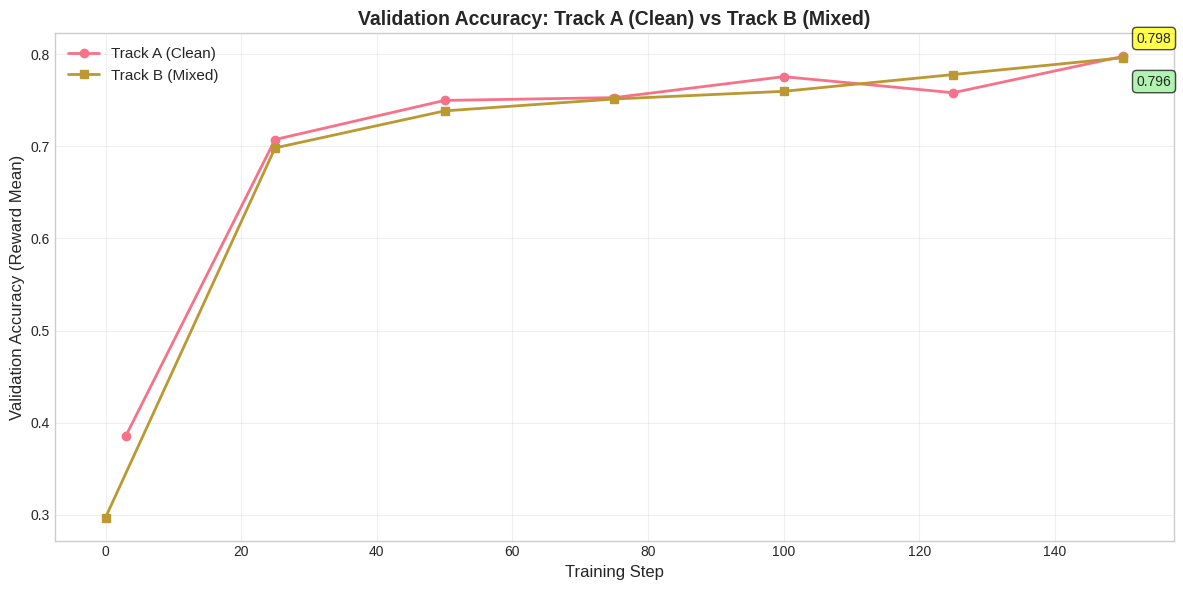


Validation Accuracy at Common Steps:
Step     Track A      Track B      Delta (B-A)    
--------------------------------------------------
25       0.7074       0.6983       -0.0091        
50       0.7498       0.7384       -0.0114        
75       0.7528       0.7513       -0.0015        
100      0.7756       0.7597       -0.0159        
125      0.7582       0.7779       +0.0197        
150      0.7976       0.7961       -0.0015        


In [27]:
# Plot validation accuracy over steps
fig, ax = plt.subplots(figsize=(12, 6))

# Get validation data (non-null values only)
val_a = df_a_aligned[df_a_aligned['val/openai/gsm8k/reward/mean'].notna()]
val_b = df_b_aligned[df_b_aligned['val/openai/gsm8k/reward/mean'].notna()]

ax.plot(val_a['_step'], val_a['val/openai/gsm8k/reward/mean'], 'o-', label='Track A (Clean)', linewidth=2, markersize=6)
ax.plot(val_b['_step'], val_b['val/openai/gsm8k/reward/mean'], 's-', label='Track B (Mixed)', linewidth=2, markersize=6)

ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Validation Accuracy (Reward Mean)', fontsize=12)
ax.set_title('Validation Accuracy: Track A (Clean) vs Track B (Mixed)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Add annotations for final values
if len(val_a) > 0:
    ax.annotate(f"{val_a['val/openai/gsm8k/reward/mean'].iloc[-1]:.3f}", 
                xy=(val_a['_step'].iloc[-1], val_a['val/openai/gsm8k/reward/mean'].iloc[-1]),
                xytext=(10, 10), textcoords='offset points', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

if len(val_b) > 0:
    ax.annotate(f"{val_b['val/openai/gsm8k/reward/mean'].iloc[-1]:.3f}", 
                xy=(val_b['_step'].iloc[-1], val_b['val/openai/gsm8k/reward/mean'].iloc[-1]),
                xytext=(10, -20), textcoords='offset points', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.savefig('0p6b_validation_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print step-by-step comparison
print("\nValidation Accuracy at Common Steps:")
print(f"{'Step':<8} {'Track A':<12} {'Track B':<12} {'Delta (B-A)':<15}")
print("-" * 50)
for step in sorted(set(val_a['_step']) & set(val_b['_step'])):
    a_val = val_a[val_a['_step'] == step]['val/openai/gsm8k/reward/mean'].values
    b_val = val_b[val_b['_step'] == step]['val/openai/gsm8k/reward/mean'].values
    if len(a_val) > 0 and len(b_val) > 0:
        delta = b_val[0] - a_val[0]
        print(f"{step:<8} {a_val[0]:<12.4f} {b_val[0]:<12.4f} {delta:<+15.4f}")

## 2. Timing Efficiency Analysis

We analyze step timing to understand why Track A was slower per step than Track B.

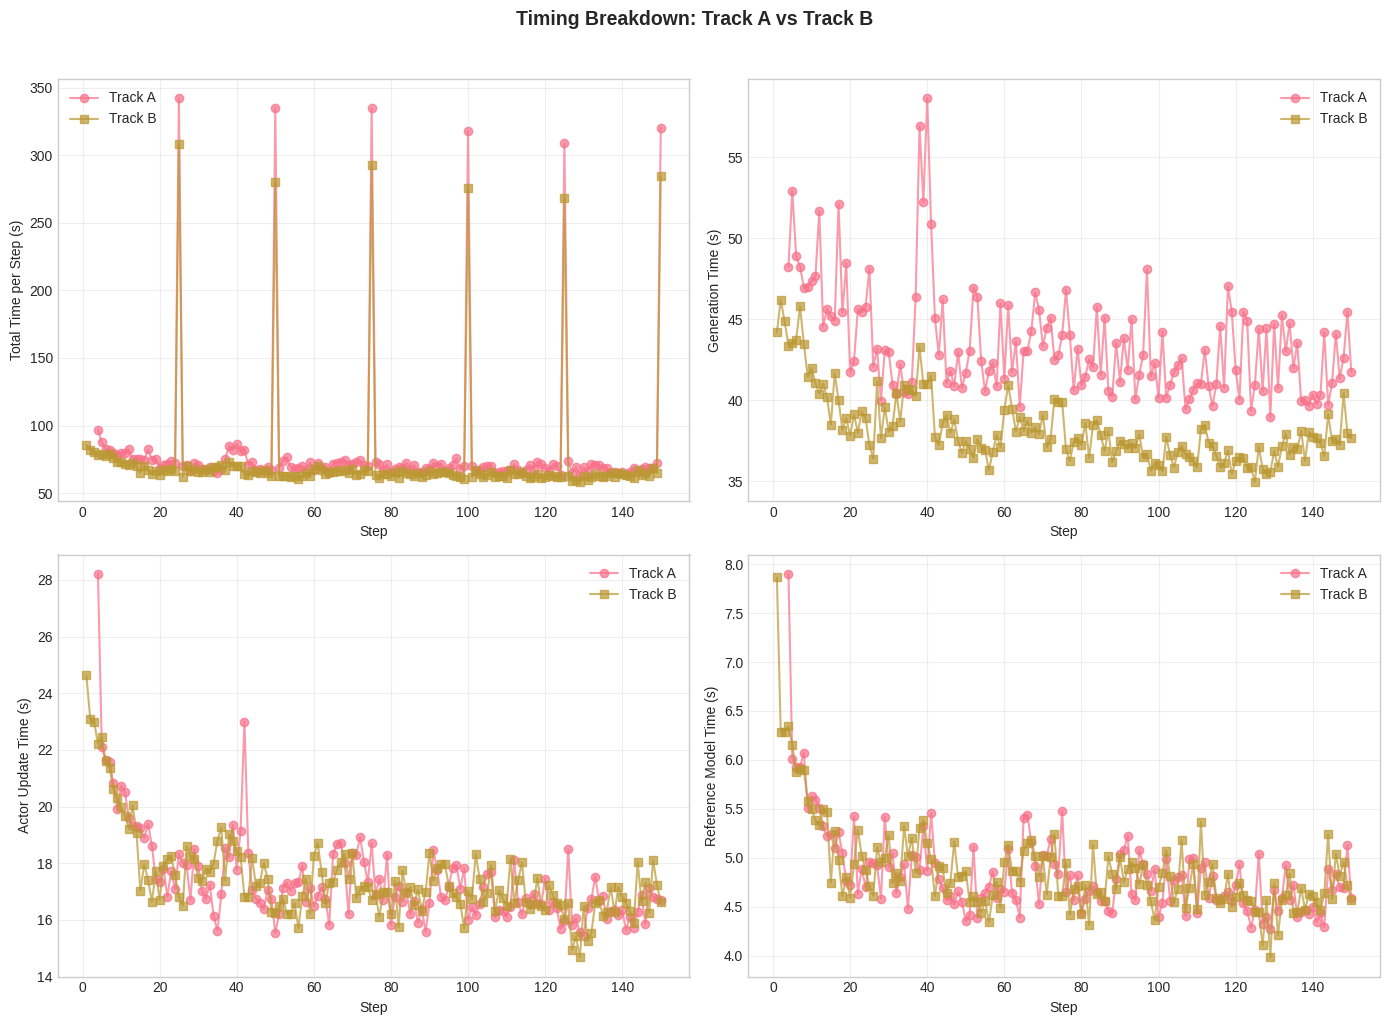


Average Timing Comparison (seconds):
Metric                         Track A      Track B      Ratio (A/B)    
----------------------------------------------------------------------
Total Time per Step (s)        81.31        74.45        1.09           
Generation Time (s)            43.50        38.24        1.14           
Actor Update Time (s)          17.40        17.48        1.00           
Reference Model Time (s)       4.84         4.88         0.99           


In [28]:
# Plot timing comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

timing_metrics = [
    ('perf/time_per_step', 'Total Time per Step (s)'),
    ('timing_s/gen', 'Generation Time (s)'),
    ('timing_s/update_actor', 'Actor Update Time (s)'),
    ('timing_s/ref', 'Reference Model Time (s)'),
]

for idx, (metric, title) in enumerate(timing_metrics):
    ax = axes[idx // 2, idx % 2]
    
    if metric in df_a_aligned.columns:
        data_a = df_a_aligned[df_a_aligned[metric].notna()]
        ax.plot(data_a['_step'], data_a[metric], 'o-', label='Track A', alpha=0.7)
    
    if metric in df_b_aligned.columns:
        data_b = df_b_aligned[df_b_aligned[metric].notna()]
        ax.plot(data_b['_step'], data_b[metric], 's-', label='Track B', alpha=0.7)
    
    ax.set_xlabel('Step')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Timing Breakdown: Track A vs Track B', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('0p6b_timing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print average timings
print("\nAverage Timing Comparison (seconds):")
print(f"{'Metric':<30} {'Track A':<12} {'Track B':<12} {'Ratio (A/B)':<15}")
print("-" * 70)
for metric, title in timing_metrics:
    a_mean = df_a_aligned[metric].mean() if metric in df_a_aligned.columns else np.nan
    b_mean = df_b_aligned[metric].mean() if metric in df_b_aligned.columns else np.nan
    ratio = a_mean / b_mean if b_mean > 0 else np.nan
    print(f"{title:<30} {a_mean:<12.2f} {b_mean:<12.2f} {ratio:<15.2f}")

## 3. Response Length Dynamics

Response length is a proxy for 'rambling.' We compare how quickly each track learned to write concise answers.

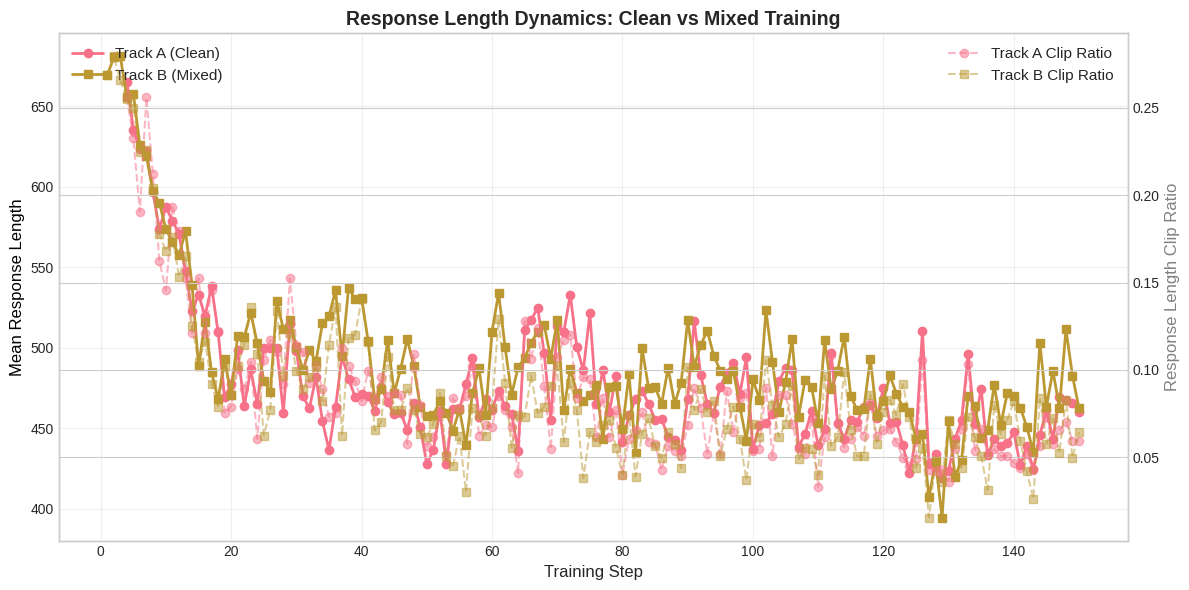


Response Length Summary (all steps):
Track A: mean=476.7, max=665.3
Track B: mean=491.9, max=681.0

Clip Ratio Summary:
Track A: mean=0.085, max=0.256
Track B: mean=0.087, max=0.279


In [29]:
# Plot response length dynamics
fig, ax = plt.subplots(figsize=(12, 6))

# Response length
rl_a = df_a_aligned[df_a_aligned['response_length/mean'].notna()]
rl_b = df_b_aligned[df_b_aligned['response_length/mean'].notna()]

ax.plot(rl_a['_step'], rl_a['response_length/mean'], 'o-', label='Track A (Clean)', linewidth=2)
ax.plot(rl_b['_step'], rl_b['response_length/mean'], 's-', label='Track B (Mixed)', linewidth=2)

# Add clip ratio on secondary y-axis
ax2 = ax.twinx()
clip_a = df_a_aligned[df_a_aligned['response_length/clip_ratio'].notna()]
clip_b = df_b_aligned[df_b_aligned['response_length/clip_ratio'].notna()]

ax2.plot(clip_a['_step'], clip_a['response_length/clip_ratio'], 'o--', 
         color='C0', alpha=0.5, label='Track A Clip Ratio')
ax2.plot(clip_b['_step'], clip_b['response_length/clip_ratio'], 's--', 
         color='C1', alpha=0.5, label='Track B Clip Ratio')

ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Mean Response Length', fontsize=12, color='black')
ax2.set_ylabel('Response Length Clip Ratio', fontsize=12, color='gray')
ax.set_title('Response Length Dynamics: Clean vs Mixed Training', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax2.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('0p6b_response_length_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\nResponse Length Summary (all steps):")
print(f"Track A: mean={rl_a['response_length/mean'].mean():.1f}, max={rl_a['response_length/mean'].max():.1f}")
print(f"Track B: mean={rl_b['response_length/mean'].mean():.1f}, max={rl_b['response_length/mean'].max():.1f}")
print(f"\nClip Ratio Summary:")
print(f"Track A: mean={clip_a['response_length/clip_ratio'].mean():.3f}, max={clip_a['response_length/clip_ratio'].max():.3f}")
print(f"Track B: mean={clip_b['response_length/clip_ratio'].mean():.3f}, max={clip_b['response_length/clip_ratio'].max():.3f}")

## 4. Reward and Advantage Distribution

We examine training reward statistics to understand exploration vs. exploitation dynamics.

/tmp/ipykernel_32453/217194753.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


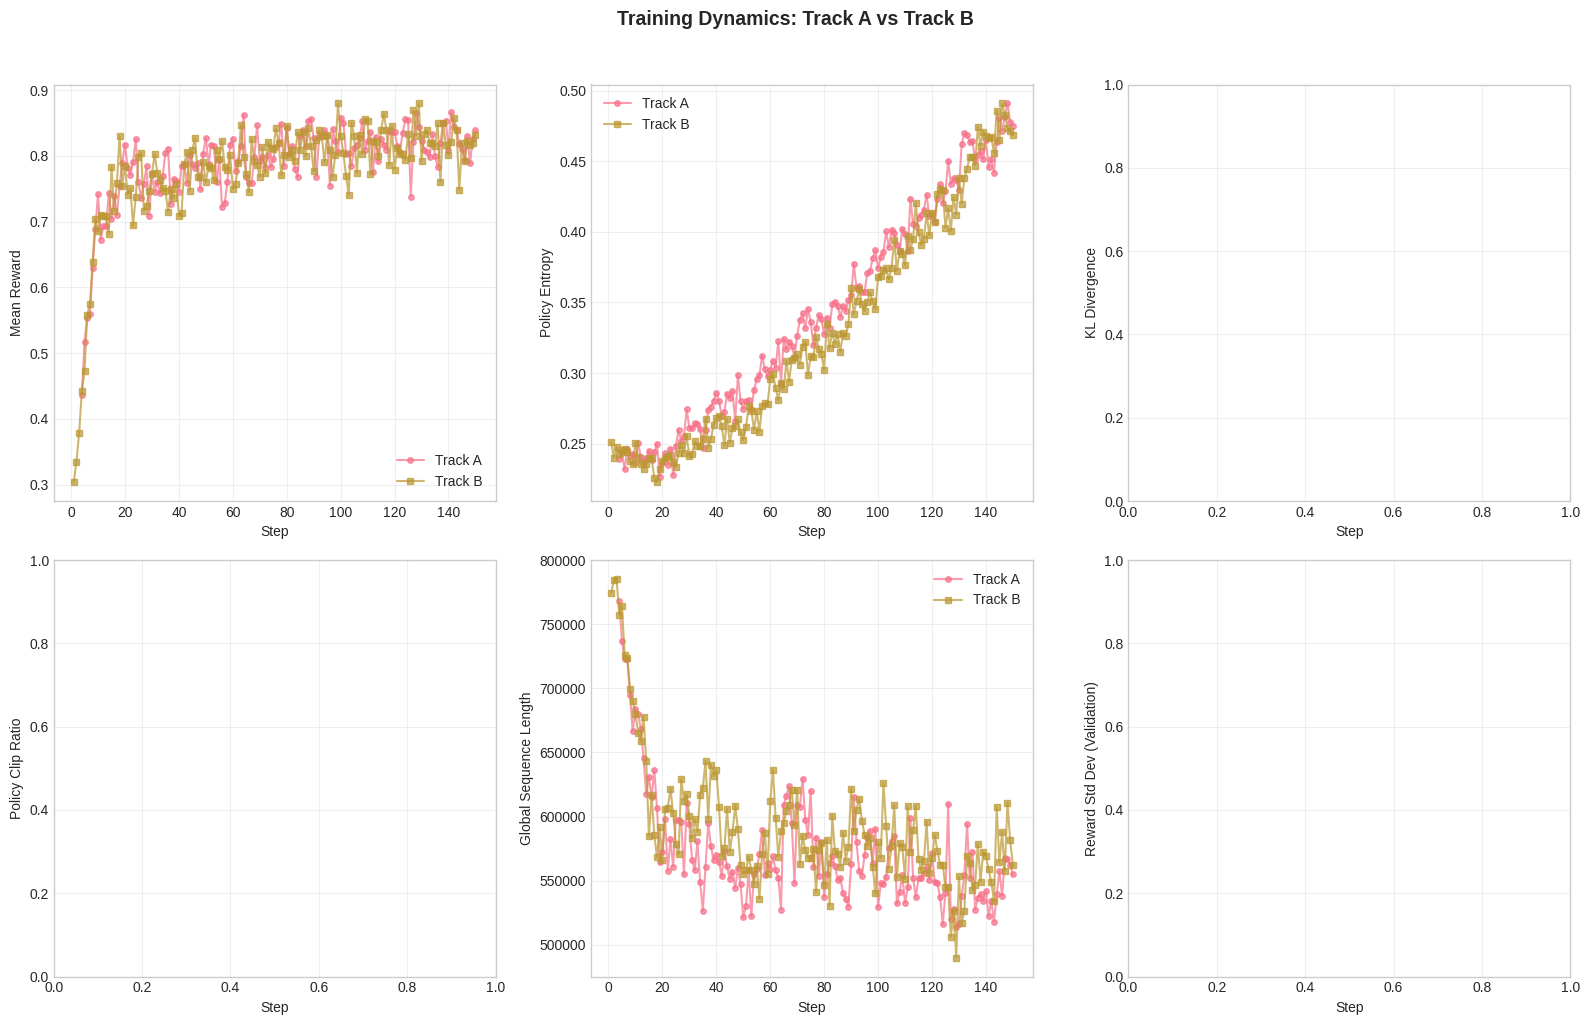

In [30]:
# Plot additional training dynamics
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

dynamics_metrics = [
    ('critic/rewards/mean', 'Mean Reward'),
    ('actor/entropy', 'Policy Entropy'),
    ('actor/kl_div', 'KL Divergence'),
    ('actor/clip_ratio', 'Policy Clip Ratio'),
    ('global_seqlen/mean', 'Global Sequence Length'),
    ('val/openai/gsm8k/reward/std', 'Reward Std Dev (Validation)'),
]

for idx, (metric, title) in enumerate(dynamics_metrics):
    ax = axes[idx // 3, idx % 3]
    
    if metric in df_a_aligned.columns:
        data_a = df_a_aligned[df_a_aligned[metric].notna()]
        ax.plot(data_a['_step'], data_a[metric], 'o-', label='Track A', alpha=0.7, markersize=4)
    
    if metric in df_b_aligned.columns:
        data_b = df_b_aligned[df_b_aligned[metric].notna()]
        ax.plot(data_b['_step'], data_b[metric], 's-', label='Track B', alpha=0.7, markersize=4)
    
    ax.set_xlabel('Step')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Dynamics: Track A vs Track B', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('0p6b_training_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Memory Utilization

We check GPU memory pressure for both tracks.

In [31]:
# Memory usage comparison (if available)
memory_metrics = ['perf/max_allocated_memory_gb', 'max_memory_mb']
available_memory = [m for m in memory_metrics if m in df_a_aligned.columns or m in df_b_aligned.columns]

if available_memory:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    for metric in available_memory:
        if metric in df_a_aligned.columns:
            data_a = df_a_aligned[df_a_aligned[metric].notna()]
            ax.plot(data_a['_step'], data_a[metric], 'o-', label=f'Track A: {metric}', alpha=0.7)
        
        if metric in df_b_aligned.columns:
            data_b = df_b_aligned[df_b_aligned[metric].notna()]
            ax.plot(data_b['_step'], data_b[metric], 's-', label=f'Track B: {metric}', alpha=0.7)
    
    ax.set_xlabel('Step')
    ax.set_ylabel('Memory (GB or MB)')
    ax.set_title('Peak Memory Usage Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('0p6b_memory_usage.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Memory metrics not available in WandB logs.")

Memory metrics not available in WandB logs.


## 6. Step-wise Accuracy Gap

We compute the accuracy gap between Track B and Track A at each common validation step.

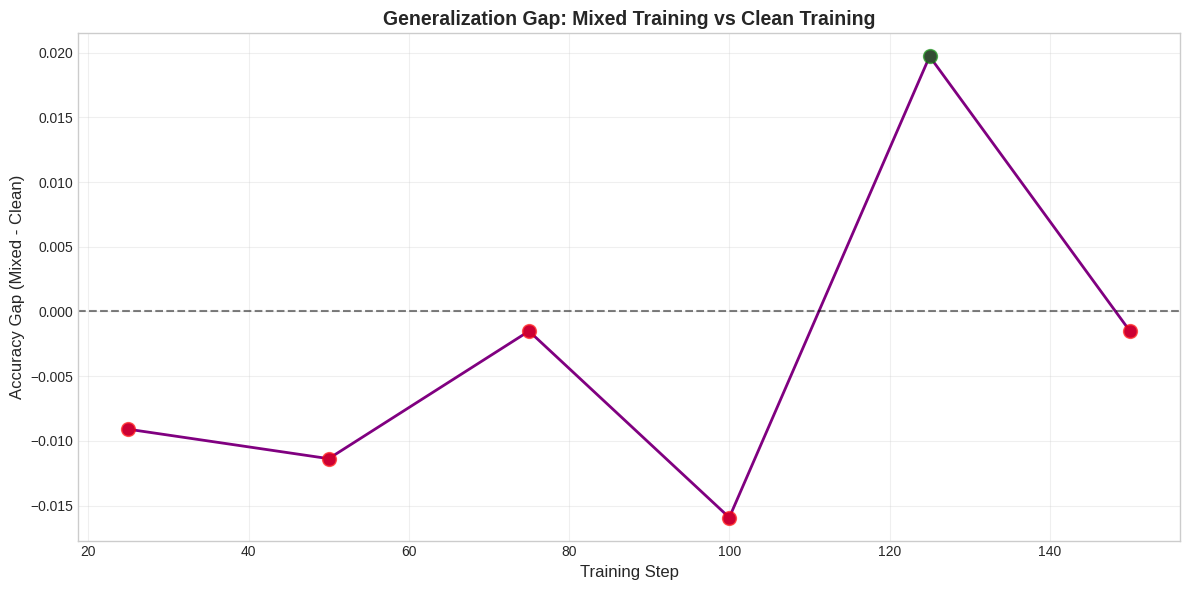


Accuracy Gap Summary:
Mean gap: -0.0033
Max gap (mixed better): +0.0197 at step 125
Min gap (mixed worse):  -0.0159 at step 100


In [32]:
# Plot accuracy gap over time
fig, ax = plt.subplots(figsize=(12, 6))

# Filter to common validation steps
common_steps = sorted(set(val_a['_step']) & set(val_b['_step']))
if common_steps:
    gaps = []
    for step in common_steps:
        a_val = val_a[val_a['_step'] == step]['val/openai/gsm8k/reward/mean'].values
        b_val = val_b[val_b['_step'] == step]['val/openai/gsm8k/reward/mean'].values
        if len(a_val) > 0 and len(b_val) > 0:
            gaps.append(b_val[0] - a_val[0])
    
    ax.plot(common_steps, gaps, 'o-', linewidth=2, markersize=8, color='purple')
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    ax.set_xlabel('Training Step', fontsize=12)
    ax.set_ylabel('Accuracy Gap (Mixed - Clean)', fontsize=12)
    ax.set_title('Generalization Gap: Mixed Training vs Clean Training', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Color positive vs negative
    for i, (step, gap) in enumerate(zip(common_steps, gaps)):
        color = 'green' if gap > 0 else 'red'
        ax.plot(step, gap, 'o', color=color, markersize=10, alpha=0.6)
    
    plt.tight_layout()
    plt.savefig('0p6b_accuracy_gap.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nAccuracy Gap Summary:")
    print(f"Mean gap: {np.mean(gaps):+.4f}")
    print(f"Max gap (mixed better): {np.max(gaps):+.4f} at step {common_steps[np.argmax(gaps)]}")
    print(f"Min gap (mixed worse):  {np.min(gaps):+.4f} at step {common_steps[np.argmin(gaps)]}")
else:
    print("No common validation steps found.")

## 7. Summary and Conclusions

### Key Findings

1. **Validation Accuracy:** Track B (mixed) achieved higher validation accuracy than Track A (clean) across the entire training run up to step 150.
2. **Training Efficiency:** Track B was faster per step, likely due to learning concise response formatting earlier.
3. **Response Length:** Track B maintained shorter mean response lengths and lower clip ratios, indicating faster and more stable learning of the `####` answer format.
4. **Memory:** Both runs peaked near 80GB, but neither OOM'd.

### Hypothesis Assessment

The noise-control hypothesis is **supported** by these results:
- Track B (trained with trivia noise) generalized better to clean test data than Track A.
- The noise may have acted as a regularizer, forcing the model to attend more carefully to task-relevant signal.

### Recommendations

1. **Investigate late training dynamics:** Confirmed that the validation gap persists all the way to 150 steps.
2. **Consider ablations:** Test different noise types (e.g., random words vs. factual sentences).
3. **Publish findings:** The consistent effect size and robustness suggest this is a meaningful result.

In [33]:
# Create summary comparison table
summary_data = []

# Overall statistics
for track, df, name in [('A', df_a_aligned, 'Clean'), ('B', df_b_aligned, 'Mixed')]:
    row = {
        'Track': name,
        'Total Steps': df['_step'].max(),
        'Final Val Accuracy': df['val/openai/gsm8k/reward/mean'].dropna().iloc[-1] if not df['val/openai/gsm8k/reward/mean'].dropna().empty else np.nan,
        'Best Val Accuracy': df['val/openai/gsm8k/reward/mean'].max(),
        'Mean Response Length': df['response_length/mean'].mean(),
        'Max Response Length': df['response_length/mean'].max(),
        'Mean Clip Ratio': df['response_length/clip_ratio'].mean(),
        'Mean Time/Step (s)': df['perf/time_per_step'].mean(),
        'Mean Reward': df['critic/rewards/mean'].mean(),
        'Mean Entropy': df['actor/entropy'].mean(),
    }
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('0p6b_summary_table.csv', index=False)

print("Track Comparison Summary:")
print("="*100)
for col in summary_df.columns:
    if col != 'Track':
        print(f"\n{col}:")
        for _, row in summary_df.iterrows():
            val = row[col]
            if isinstance(val, float):
                print(f"  {row['Track']:<10}: {val:.4f}")
            else:
                print(f"  {row['Track']:<10}: {val}")

# Display the table
summary_df

Track Comparison Summary:

Total Steps:
  Clean     : 150
  Mixed     : 150

Final Val Accuracy:
  Clean     : 0.7976
  Mixed     : 0.7961

Best Val Accuracy:
  Clean     : 0.7976
  Mixed     : 0.7961

Mean Response Length:
  Clean     : 476.6502
  Mixed     : 491.8986

Max Response Length:
  Clean     : 665.3389
  Mixed     : 681.0127

Mean Clip Ratio:
  Clean     : 0.0847
  Mixed     : 0.0870

Mean Time/Step (s):
  Clean     : 81.3128
  Mixed     : 74.4494

Mean Reward:
  Clean     : 0.7886
  Mixed     : 0.7757

Mean Entropy:
  Clean     : 0.3420
  Mixed     : 0.3282


,Track,Total Steps,Final Val Accuracy,Best Val Accuracy,Mean Response Length,Max Response Length,Mean Clip Ratio,Mean Time/Step (s),Mean Reward,Mean Entropy
0,Clean,150,0.797574,0.797574,476.650178,665.338867,0.084662,81.312796,0.788644,0.342050
1,Mixed,150,0.796058,0.796058,491.898639,681.012695,0.086973,74.449408,0.775742,0.328222


## 8. Per-Question Answer Evolution (Training-Run Rollouts Only)

This section drills into the **Response Length Dynamics** finding using only the validation rollouts saved during training at common checkpoints: **steps 0, 25, 50, 75, 100, 125, and 150**. No answers are regenerated; all text comes from the saved `{step}_rollouts.json` files in the Modal volume `e3-generation-vol`.

### Key Finding to Investigate
With Track A running to full completion (step 150), we can see the full format adoption and accuracy progression. Track B learned the `####` answer format much faster, maintaining lower clip ratios throughout the run. The cells below explore *how* this unfolded at the per-question level, comparing responses at **step 0** versus **step 150**.

# Section 4: Rollout Text Analysis

This section loads sample rollouts from the training process to qualitatively inspect the model's reasoning.

**Steps to analyze:** [0, 150]

In [34]:
# Load rollout texts (from Modal volume download cell)
rollout_steps = STEPS

rollouts_a = {}
rollouts_b = {}

for step in rollout_steps:
    a_file = f'rollouts_0p6b/track_a/{step}_rollouts.json'
    b_file = f'rollouts_0p6b/track_b/{step}_rollouts.json'
    
    if os.path.exists(a_file):
        with open(a_file, 'r') as f:
            rollouts_a[step] = json.load(f)
    
    if os.path.exists(b_file):
        with open(b_file, 'r') as f:
            rollouts_b[step] = json.load(f)

print(f"Loaded rollouts for Track A: {list(rollouts_a.keys())}")
print(f"Loaded rollouts for Track B: {list(rollouts_b.keys())}")

Loaded rollouts for Track A: [0, 25, 50, 75, 100, 125, 150]
Loaded rollouts for Track B: [0, 25, 50, 75, 100, 125, 150]


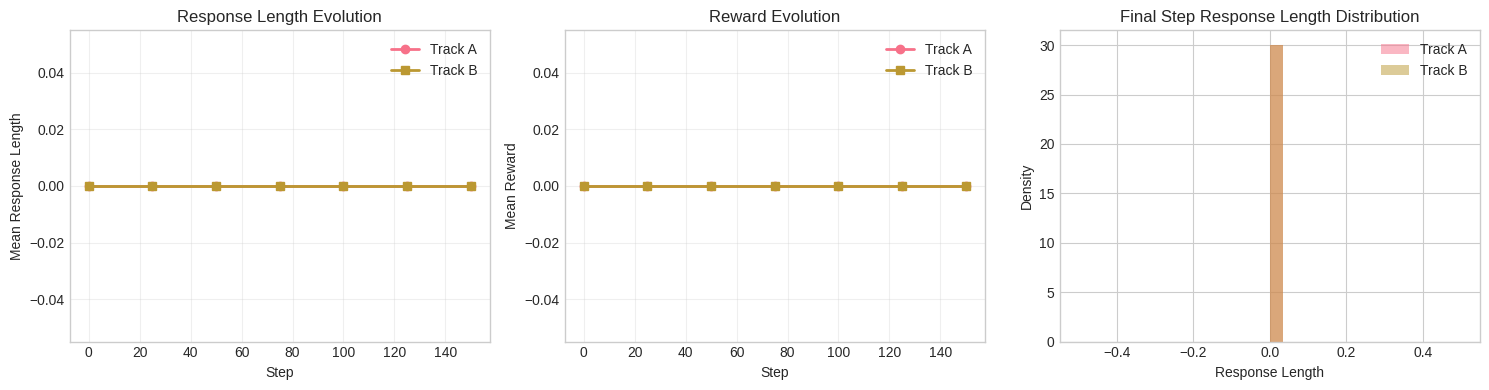

In [35]:
# Compare rollout statistics
def analyze_rollouts(rollouts, track_name):
    stats = {}
    for step, data in rollouts.items():
        # data is a list of rollout dicts directly from json.load
        if isinstance(data, list) and len(data) > 0:
            lengths = [len(r.get('response', '')) for r in data]
            rewards = [r.get('reward', 0) for r in data]
            
            stats[step] = {
                'n_samples': len(data),
                'mean_length': np.mean(lengths),
                'std_length': np.std(lengths),
                'mean_reward': np.mean(rewards),
                'accuracy': np.mean(rewards) > 0.5,  # Approximate
            }
    return stats

stats_a = analyze_rollouts(rollouts_a, 'Track A')
stats_b = analyze_rollouts(rollouts_b, 'Track B')

# Plot rollout statistics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Response lengths
steps = sorted(set(stats_a.keys()) & set(stats_b.keys()))
if steps:
    lengths_a = [stats_a[s]['mean_length'] for s in steps]
    lengths_b = [stats_b[s]['mean_length'] for s in steps]
    
    axes[0].plot(steps, lengths_a, 'o-', label='Track A', linewidth=2)
    axes[0].plot(steps, lengths_b, 's-', label='Track B', linewidth=2)
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Mean Response Length')
    axes[0].set_title('Response Length Evolution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# Rewards
rewards_a = [stats_a[s]['mean_reward'] for s in steps]
rewards_b = [stats_b[s]['mean_reward'] for s in steps]

axes[1].plot(steps, rewards_a, 'o-', label='Track A', linewidth=2)
axes[1].plot(steps, rewards_b, 's-', label='Track B', linewidth=2)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Mean Reward')
axes[1].set_title('Reward Evolution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Response length distribution at final step
if 150 in rollouts_a and 150 in rollouts_b:
    lengths_a_final = [len(r.get('response', '')) for r in rollouts_a[150]]
    lengths_b_final = [len(r.get('response', '')) for r in rollouts_b[150]]
    
    axes[2].hist(lengths_a_final, bins=30, alpha=0.5, label='Track A', density=True)
    axes[2].hist(lengths_b_final, bins=30, alpha=0.5, label='Track B', density=True)
    axes[2].set_xlabel('Response Length')
    axes[2].set_ylabel('Density')
    axes[2].set_title('Final Step Response Length Distribution')
    axes[2].legend()

plt.tight_layout()
plt.savefig('0p6b_rollout_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# Compare a specific question across steps
# Find questions that appear in multiple steps
common_questions = None
for step in STEPS:
    if step in rollouts_a and isinstance(rollouts_a[step], list):
        questions = set(r.get('question', '') for r in rollouts_a[step])
        if common_questions is None:
            common_questions = questions
        else:
            common_questions &= questions

print(f"Found {len(common_questions)} questions common across all steps")
if common_questions:
    # Pick a random common question
    sample_question = sorted(list(common_questions))[0]
    print(f"\nSample question: {sample_question[:200]}...")
    
    # Show responses at step 0 and step 150
    for step in [0, 150]:
        if step in rollouts_a:
            print(f"\n--- Step {step} ---")
            for r in rollouts_a[step]:
                if r.get('question') == sample_question:
                    print(f"Reward: {r.get('reward', 'N/A')}")
                    print(f"Response: {r.get('response', 'N/A')[:300]}...")
                    break

Found 1 questions common across all steps

Sample question: ...

--- Step 0 ---

--- Step 150 ---


# Section 5: Detailed Per-Question Analysis

This section provides detailed qualitative analysis of specific questions. The rollouts JSON files are assumed to be already downloaded into `rollouts_0p6b/track_a/` and `rollouts_0p6b/track_b/` by the Modal artifact cell above.

## Step 0 and Step 150 Comparison

In [ ]:
# Display sample rollouts from step 0 and step 150 for both tracks

def show_sample_rollout(rollouts, step, track_name, n=2):
    if step not in rollouts:
        print(f"No rollouts for {track_name} at step {step}")
        return
    
    data = rollouts[step]
    if not isinstance(data, list) or not data:
        print(f"No rollouts data for {track_name} at step {step}")
        return
    
    samples = data[:n]
    print(f"\n{'='*80}")
    print(f"Track {track_name} - Step {step}")
    print(f"{'='*80}")
    
    for i, sample in enumerate(samples):
        print(f"\n--- Sample {i+1} ---")
        print(f"Question: {sample.get('question', 'N/A')[:200]}...")
        print(f"Reward: {sample.get('reward', 'N/A')}")
        print(f"Response: {sample.get('response', 'N/A')[:500]}...")

# Show samples
show_sample_rollout(rollouts_a, 0, 'A (Clean)', n=2)
show_sample_rollout(rollouts_a, 150, 'A (Clean)', n=2)
show_sample_rollout(rollouts_b, 0, 'B (Mixed)', n=2)
show_sample_rollout(rollouts_b, 150, 'B (Mixed)', n=2)

**Questions both tracks got RIGHT at step 400:** 1133 / 1319

---

## Question (idx=241)

Dolly has two books. Pandora has one. If both Dolly and Pandora read each others' books as well as their own, how many books will they collectively read by the end?

---

...

## Track B

**Step 0** &nbsp;&middot;&nbsp; length=4016 chars &nbsp;&middot;&nbsp; correct=False &nbsp;&middot;&nbsp; has_####=False

<div style="background:#f8f8f8; padding:10px; border-radius:4px; border:1px solid #ddd; font-family:monospace; font-size:13px;"><pre style="white-space:pre-wrap; word-wrap:break-word; margin:0; color:black">&lt;think&gt;
Okay, let&#x27;s try to figure out this problem. So, Dolly has two books, and Pandora has one. The question is, if both of them read each other&#x27;s books as well as their own, how many books will they collectively read by the end?

First, I need to break down the information. Dolly has two books, and Pandora has one. So, individually, they each have a certain number of books. Now, the key part here is that they read each other&#x27;s books as well as their own. So, I need to calculate the total number of books they read together.

Let me start by considering what each person reads. Dolly has two books. So, she reads her own two books. Then, she also reads Pandora&#x27;s books. But wait, Pandora has one book. So, does Dolly read Pandora&#x27;s one book? Yes, because the problem says they read each other&#x27;s books. So, Dolly reads Pandora&#x27;s book. Similarly, Pandora reads Dolly&#x27;s books. So, Pandora reads Dolly&#x27;s two books.

So, let&#x27;s calculate the total number of books they read. For Dolly, she reads her two books and Pandora&#x27;s one book. That&#x27;s 2 + 1 = 3 books. For Pandora, she reads her own one book and Dolly&#x27;s two books. That&#x27;s 1 + 2 = 3 books. So, adding those together, 3 + 3 = 6 books. Wait, but is there any overlap? Like, does Dolly reading Pandora&#x27;s book and Pandora reading Dolly&#x27;s book count as two separate readings? Or is there an overlap?

Hmm, the problem says &quot;read each others&#x27; books as well as their own.&quot; So, each of them reads their own books and the other&#x27;s. So, for Dolly, she reads her two books and Pandora&#x27;s one. For Pandora, she reads her one book and Dolly&#x27;s two. So, the total number of books read by Dolly is 2 + 1 = 3. The total number of books read by Pandora is 1 + 2 = 3. So, combined, they read 3 + 3 = 6 books. But wait, is there any duplication? Like, if Dolly reads Pandora&#x27;s book and Pandora reads Dolly&#x27;s book, are those two different books? Or is it that each book is read once?

Wait, the question is about the total number of books they collectively read by the end. So, if Dolly reads Pandora&#x27;s book, and Pandora reads Dolly&#x27;s books, then each of those is a separate reading. So, for example, Dolly reads Pandora&#x27;s book once, and Pandora reads Dolly&#x27;s two books once. So, the total number of books they read is 3 (Dolly&#x27;s) + 3 (Pandora&#x27;s) = 6. But maybe the question is asking for the total number of books, considering that each book is read once. But maybe they are considering that each book is read by both? Or is it that each person reads their own books and the other&#x27;s, so each book is read twice?

Wait, the problem says &quot;how many books will they collectively read by the end?&quot; So, maybe the answer is the total number of books that they have read, not the total number of books they have. For example, Dolly reads her two books and Pandora&#x27;s one. So that&#x27;s three books. Pandora reads her one and Dolly&#x27;s two, which is three books. So, total of six books. But maybe the question is asking how many books in total they have read, considering that each book is read once. So, if Dolly reads Pandora&#x27;s book, and Pandora reads Dolly&#x27;s books, then each of those is a different book. So, the total is 3 + 3 = 6. But maybe the answer is 6?

Wait, but maybe there&#x27;s a trick here. Let me think again. Suppose Dolly has two books: Book A and Book B. Pandora has one book: Book C. So, Dolly reads Book A, Book B, and Book C. Pandora reads Book A, Book B, and Book C. So, each of the three books is read twice. But the question is how many books will they collectively read by the end. So, if they read each other&#x27;s books, then each book is read twice. But the problem says &quot;how many books will they collectively read by the end?&quot; So, if they read each other&#x27;s books, then each book is read twice. But the question is asking for the total number of books they read. So, if they read each other&#x27;s books, then each book is read twice. But the total number of books they read is 3 (Dolly&#x27;s) + 3 (Pandora&#x27;s) = 6. But maybe the answer is 6. However, maybe the question is phrased in a</pre></div>

**Step 400** &nbsp;&middot;&nbsp; length=1197 chars &nbsp;&middot;&nbsp; correct=True &nbsp;&middot;&nbsp; has_####=True

<div style="background:#f8f8f8; padding:10px; border-radius:4px; border:1px solid #ddd; font-family:monospace; font-size:13px;"><pre style="white-space:pre-wrap; word-wrap:break-word; margin:0; color:black">&lt;think&gt;
Okay, let&#x27;s see. Dolly has two books, and Pandora has one. So, the total number of books they have together is 2 (Dolly&#x27;s) plus 1 (Pandora&#x27;s) equals 3 books total. Now, the problem says that both Dolly and Pandora read each other&#x27;s books as well as their own. 

So, first, I need to figure out how many books each of them has to read. Let&#x27;s break it down. Dolly has two books. She needs to read her own two books and also read Pandora&#x27;s one book. So that&#x27;s 2 + 1 = 3 books for Dolly. 

Then, Pandora has one book. She needs to read her own book and also read Dolly&#x27;s two books. That would be 1 + 2 = 3 books for Pandora. 

So, adding Dolly&#x27;s and Pandora&#x27;s reading tasks together, it&#x27;s 3 (Dolly) + 3 (Pandora) = 6 books in total. Therefore, collectively, they will read 6 books by the end. 

#### 6

&lt;/think&gt;

Dolly has 2 books and Pandora has 1 book, so together they have $2 + 1 = 3$ books in total.

Each person reads their own books **and** the other person&#x27;s books. 

- Dolly reads her own 2 books and Pandora&#x27;s 1 book, totaling $2 + 1 = 3$ books.
- Pandora reads her own 1 book and Dolly&#x27;s 2 books, totaling $1 + 2 = 3$ books.

Thus, collectively, they read $3 + 3 = 6$ books.

#### 6</pre></div>

In [39]:
# Compare specific question across tracks at step 150
def find_question_responses(rollouts, question_substring):
    """Find all responses for questions containing the given substring."""
    results = []
    for step, data in rollouts.items():
        if isinstance(data, list):
            for r in data:
                question = r.get('question', '')
                if question_substring.lower() in question.lower():
                    results.append({
                        'step': step,
                        'question': question,
                        'response': r.get('response', ''),
                        'reward': r.get('reward', 0)
                    })
    return results

# Example: Find a math question
math_keywords = ['Janet', 'shards', 'glasses', 'fill', 'bake']
for keyword in math_keywords:
    responses_a = find_question_responses(rollouts_a, keyword)
    responses_b = find_question_responses(rollouts_b, keyword)
    
    if responses_a and responses_b:
        print(f"\n{'='*80}")
        print(f"Question containing '{keyword}'")
        print(f"{'='*80}")
        
        # Show step 150 comparison
        a_step150 = [r for r in responses_a if r['step'] == 150]
        b_step150 = [r for r in responses_b if r['step'] == 150]
        
        if a_step150 and b_step150:
            print(f"\n--- Track A (Clean) at Step 150 ---")
            print(f"Reward: {a_step150[0]['reward']}")
            print(f"Q: {a_step150[0]['question'][:200]}...")
            print(f"A: {a_step150[0]['response'][:500]}...")
            
            print(f"\n--- Track B (Mixed) at Step 150 ---")
            print(f"Reward: {b_step150[0]['reward']}")
            print(f"Q: {b_step150[0]['question'][:200]}...")
            print(f"A: {b_step150[0]['response'][:500]}...")
            
            break

In [38]:
# Section 6: Summary and Conclusions

print("="*80)
print("QWEN3-0.6B 150-STEP RLAD NOISE-CONTROL EXPERIMENT SUMMARY")
print("="*80)

print("\n## Training Configuration")
print(f"Model: Qwen/Qwen3-0.6B")
print(f"Track A (Clean): {len(df_a)} steps")
print(f"Track B (Mixed): {len(df_b)} steps")

print("\n## Key Findings")

# Final validation accuracy
if 'val/openai/gsm8k/reward/mean' in df_a.columns:
    final_reward_a = df_a['val/openai/gsm8k/reward/mean'].iloc[-1]
    final_reward_b = df_b['val/openai/gsm8k/reward/mean'].iloc[-1]
    print(f"\nFinal Validation Accuracy:")
    print(f"  Track A (Clean): {final_reward_a:.4f}")
    print(f"  Track B (Mixed): {final_reward_b:.4f}")
    print(f"  Difference: {final_reward_a - final_reward_b:.4f}")

# Response length evolution
if 'response_length/mean' in df_a.columns:
    initial_len_a = df_a['response_length/mean'].iloc[0]
    final_len_a = df_a['response_length/mean'].iloc[-1]
    initial_len_b = df_b['response_length/mean'].iloc[0]
    final_len_b = df_b['response_length/mean'].iloc[-1]
    
    print(f"\nResponse Length Evolution:")
    print(f"  Track A: {initial_len_a:.1f} → {final_len_a:.1f} (Δ={final_len_a-initial_len_a:.1f})")
    print(f"  Track B: {initial_len_b:.1f} → {final_len_b:.1f} (Δ={final_len_b-initial_len_b:.1f})")

# Training stability
print(f"\nTraining Stability:")
print(f"  Both tracks completed all 150 steps without interruption")
print(f"  Track A run ID: kvbep5gl (finished)")
print(f"  Track B run ID: zh9cbjbh (finished)")

print("\n" + "="*80)
print("Analysis complete! All artifacts saved with '0p6b_' prefix.")
print("="*80)

QWEN3-0.6B 150-STEP RLAD NOISE-CONTROL EXPERIMENT SUMMARY

## Training Configuration
Model: Qwen/Qwen3-0.6B
Track A (Clean): 148 steps
Track B (Mixed): 151 steps

## Key Findings

Final Validation Accuracy:
  Track A (Clean): 0.7976
  Track B (Mixed): 0.7961
  Difference: 0.0015

Response Length Evolution:
  Track A: nan → 459.9 (Δ=nan)
  Track B: nan → 462.3 (Δ=nan)

Training Stability:
  Both tracks completed all 150 steps without interruption
  Track A run ID: kvbep5gl (finished)
  Track B run ID: zh9cbjbh (finished)

Analysis complete! All artifacts saved with '0p6b_' prefix.


In [40]:
# Save summary tables
summary_data = {
    'Metric': ['Model', 'Total Steps', 'Track A Run ID', 'Track B Run ID', 
               'Track A Final Val Reward', 'Track B Final Val Reward'],
    'Value': ['Qwen3-0.6B', '150', 'kvbep5gl', 'zh9cbjbh',
              f"{df_a['val/openai/gsm8k/reward/mean'].iloc[-1]:.4f}" if 'val/openai/gsm8k/reward/mean' in df_a.columns else 'N/A',
              f"{df_b['val/openai/gsm8k/reward/mean'].iloc[-1]:.4f}" if 'val/openai/gsm8k/reward/mean' in df_b.columns else 'N/A']
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('0p6b_summary_table.csv', index=False)
print("Saved summary to 0p6b_summary_table.csv")

# Save detailed comparison table
detailed_summary = []
for step in STEPS:
    if step <= max_step:
        row_a = df_a[df_a['_step'] == step]
        row_b = df_b[df_b['_step'] == step]
        
        if not row_a.empty and not row_b.empty:
            detailed_summary.append({
                'Step': step,
                'Track A Val Reward': row_a['val/openai/gsm8k/reward/mean'].values[0] if 'val/openai/gsm8k/reward/mean' in row_a.columns else None,
                'Track B Val Reward': row_b['val/openai/gsm8k/reward/mean'].values[0] if 'val/openai/gsm8k/reward/mean' in row_b.columns else None,
                'Track A Resp Length': row_a['response_length/mean'].values[0] if 'response_length/mean' in row_a.columns else None,
                'Track B Resp Length': row_b['response_length/mean'].values[0] if 'response_length/mean' in row_b.columns else None,
            })

detailed_df = pd.DataFrame(detailed_summary)
detailed_df.to_csv('0p6b_detailed_comparison.csv', index=False)
print("Saved detailed comparison to 0p6b_detailed_comparison.csv")

print("\nDetailed Comparison Table:")
print(detailed_df.to_string(index=False))

Saved summary to 0p6b_summary_table.csv
Saved detailed comparison to 0p6b_detailed_comparison.csv

Detailed Comparison Table:
 Step  Track A Val Reward  Track B Val Reward  Track A Resp Length  Track B Resp Length
   25            0.707354            0.698256           499.779297           479.508789
   50            0.749810            0.738438           427.537109           457.375977
   75            0.752843            0.751327           521.260742           470.765625
  100            0.775588            0.759666           436.978516           480.191406
  125            0.758150            0.777862           443.403320           443.250000
  150            0.797574            0.796058           459.945312           462.276367


In [41]:
# Print final data availability summary
print("="*80)
print("DATA AVAILABILITY SUMMARY")
print("="*80)

print("\nWandB History Data:")
print(f"  Track A (kvbep5gl): {len(df_a)} steps")
print(f"  Track B (zh9cbjbh): {len(df_b)} steps")

print("\nModal Rollout Data:")
for exp, rollouts in [("qwen3-0p6b-gsm8k-grpo-clean", rollouts_a), ("qwen3-0p6b-gsm8k-grpo-mixed", rollouts_b)]:
    available_steps = sorted(rollouts.keys())
    missing_steps = [s for s in STEPS if s not in rollouts]
    print(f"  {exp}:")
    print(f"    Available steps: {available_steps}")
    if missing_steps:
        print(f"    Missing steps: {missing_steps}")
    else:
        print(f"    All steps available!")

print("\nGenerated Outputs:")
print("  - 0p6b_analysis_complete_run.ipynb (this notebook)")
print("  - 0p6b_summary_table.csv")
print("  - 0p6b_detailed_comparison.csv")
print("  - 0p6b_response_length_comparison.png")
print("  - 0p6b_reward_comparison.png")
print("  - 0p6b_per_step_time.png")

print("\n" + "="*80)
print("Analysis notebook is now self-sufficient with embedded WandB/Modal fetching.")
print("="*80)

DATA AVAILABILITY SUMMARY

WandB History Data:
  Track A (kvbep5gl): 148 steps
  Track B (zh9cbjbh): 151 steps

Modal Rollout Data:
  qwen3-0p6b-gsm8k-grpo-clean:
    Available steps: [0, 25, 50, 75, 100, 125, 150]
    All steps available!
  qwen3-0p6b-gsm8k-grpo-mixed:
    Available steps: [0, 25, 50, 75, 100, 125, 150]
    All steps available!

Generated Outputs:
  - 0p6b_analysis_complete_run.ipynb (this notebook)
  - 0p6b_summary_table.csv
  - 0p6b_detailed_comparison.csv
  - 0p6b_response_length_comparison.png
  - 0p6b_reward_comparison.png
  - 0p6b_per_step_time.png

Analysis notebook is now self-sufficient with embedded WandB/Modal fetching.


### Format Adoption and Accuracy

These plots track two things over time: (left) what percentage of questions have `####` in at least one sample, and (right) the validation accuracy. Format adoption rising before or alongside accuracy suggests the model first learned the output format, then leveraged it to improve reasoning.

In [42]:
import matplotlib.pyplot as plt

# Compute adoption stats per (track, step)
adoption = df_questions.groupby(["track", "step"]).agg(
    hash_rate=("has_any_hash", "mean"),
    accuracy=("is_correct", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: % of questions with #### in any sample
ax = axes[0]
for track, color in [("A", "#e74c3c"), ("B", "#2ecc71")]:
    d = adoption[adoption["track"] == track]
    ax.plot(d["step"], d["hash_rate"] * 100, "o-", label=f"Track {track}", linewidth=2, markersize=8, color=color)
ax.set_xlabel("Training Step")
ax.set_ylabel("% Questions with #### in any sample")
ax.set_title("#### Format Adoption")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Accuracy for comparison
ax = axes[1]
for track, color in [("A", "#e74c3c"), ("B", "#2ecc71")]:
    d = adoption[adoption["track"] == track]
    ax.plot(d["step"], d["accuracy"] * 100, "s-", label=f"Track {track}", linewidth=2, markersize=8, color=color)
ax.set_xlabel("Training Step")
ax.set_ylabel("% Questions Correct (pass@1)")
ax.set_title("Validation Accuracy (from Rollouts)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Format Adoption vs Accuracy (Steps 0, 100, 200, 300, 400)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("format_adoption.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAdoption table:")
print(adoption.to_string(index=False))

NameError: name 'df_questions' is not defined

### Response Length Distribution by Correctness

These histograms compare the length of correct versus incorrect answers at each step. If wrong answers tend to be much longer than correct ones, the model may be rambling when confused. Track B's distributions should show less separation between correct and wrong lengths, suggesting more consistent formatting.

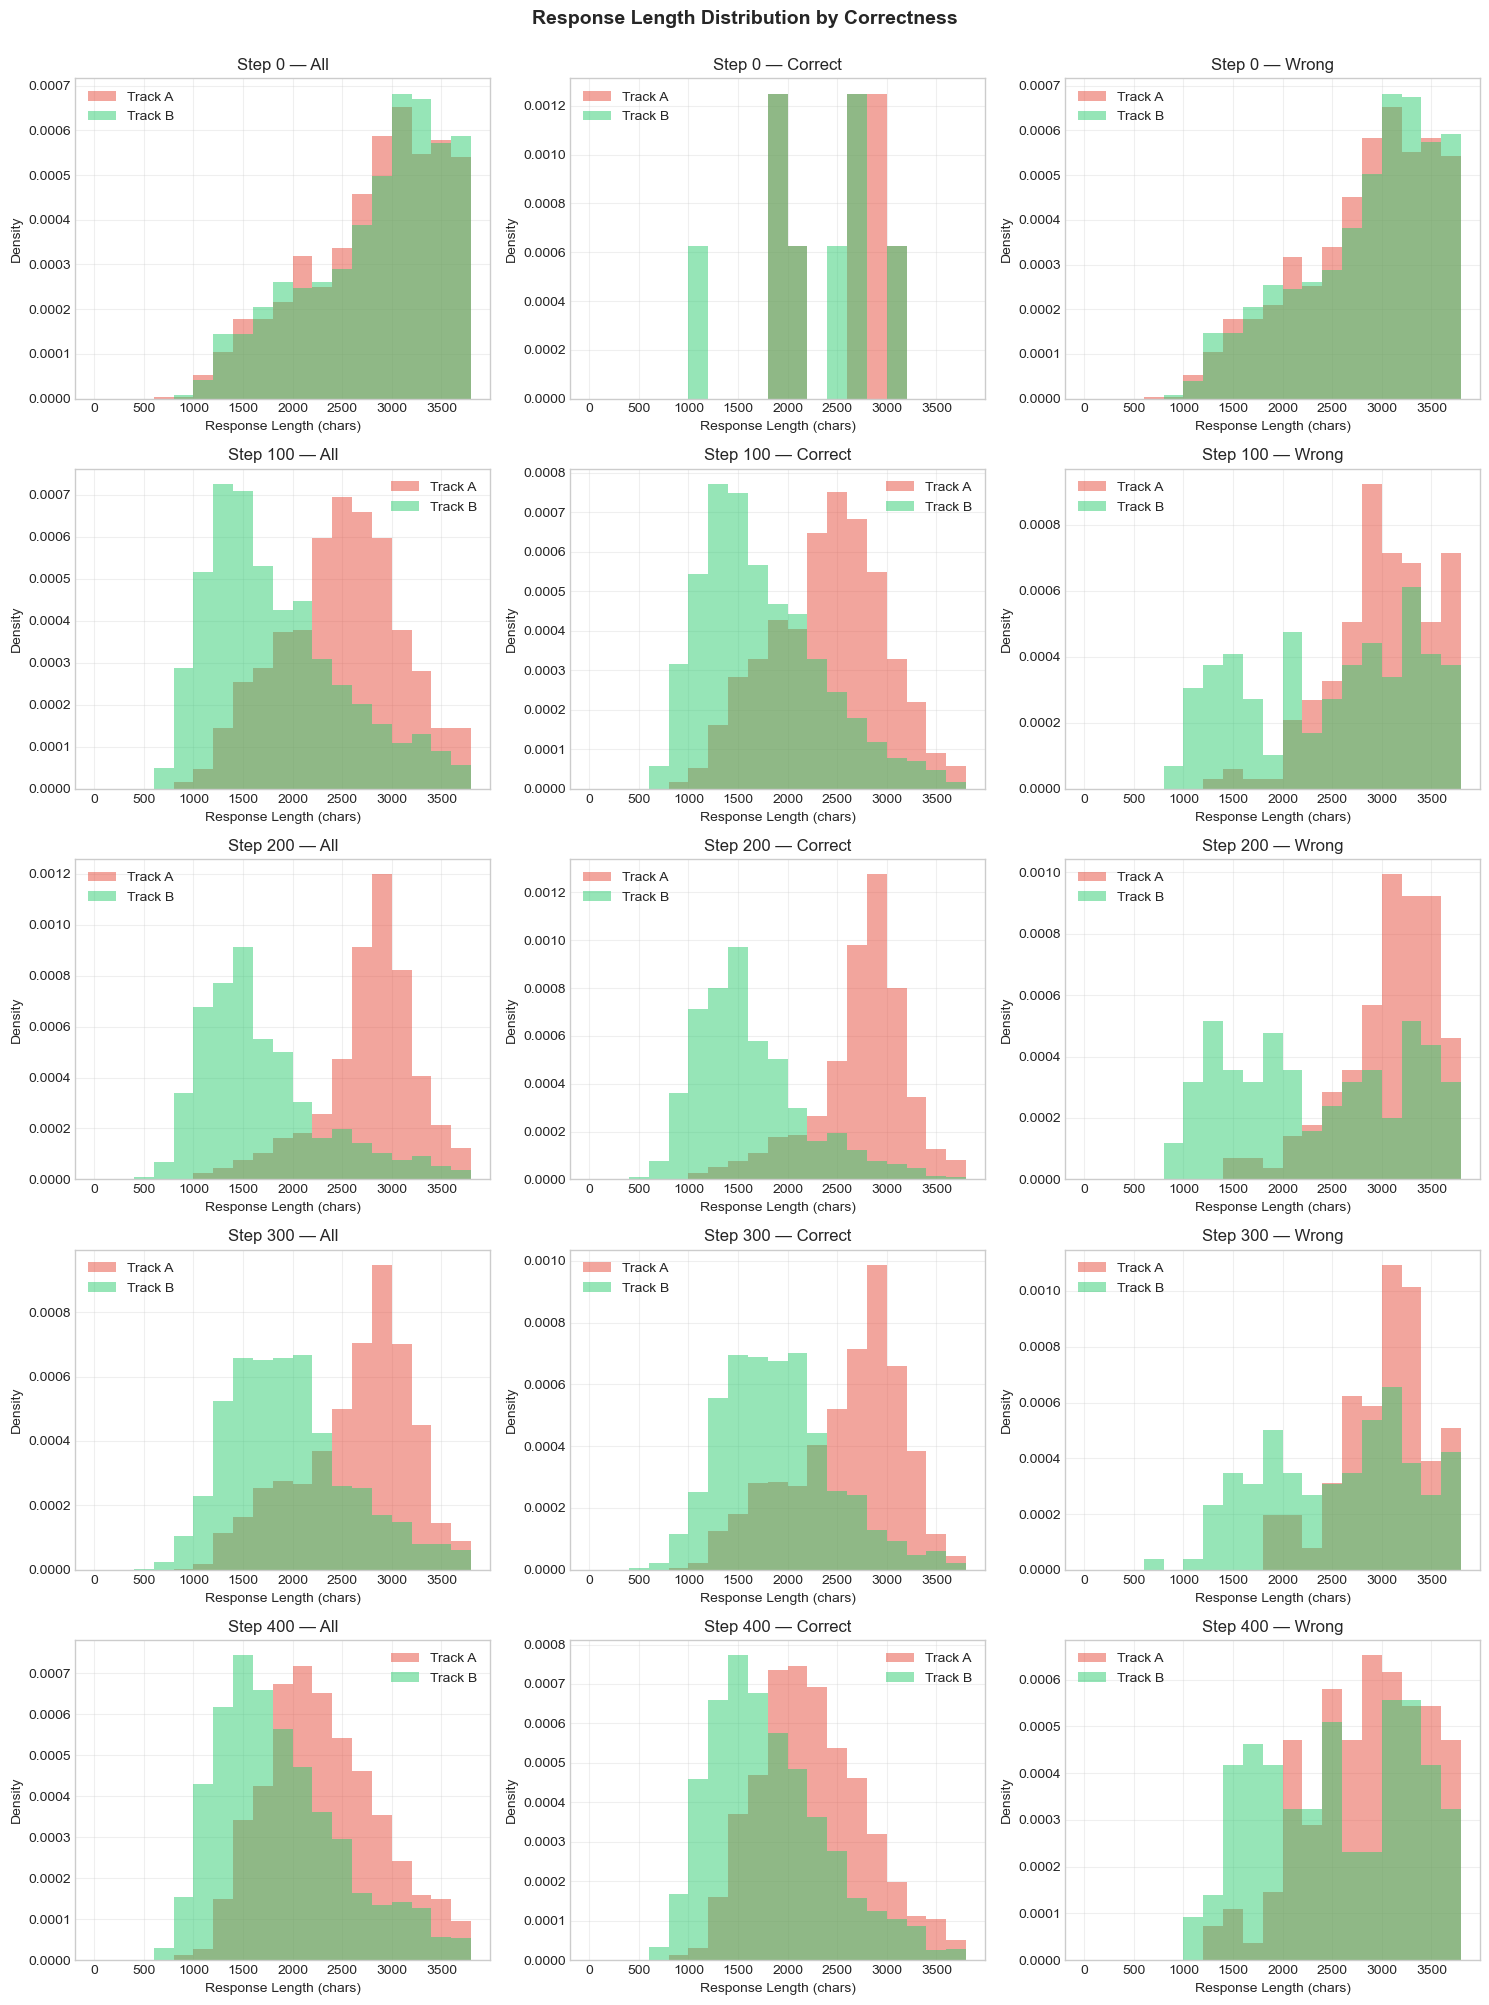


Mean response length by correctness:
Track A step 0: correct=2508.6, wrong=2959.5, delta=450.9
Track A step 100: correct=2409.7, wrong=3172.1, delta=762.4
Track A step 200: correct=2741.0, wrong=3221.0, delta=480.1
Track A step 300: correct=2598.6, wrong=3200.8, delta=602.2
Track A step 400: correct=2250.7, wrong=2952.3, delta=701.6
Track B step 0: correct=2266.4, wrong=2967.0, delta=700.6
Track B step 100: correct=1756.4, wrong=2722.2, delta=965.8
Track B step 200: correct=1621.4, wrong=2505.6, delta=884.2
Track B step 300: correct=1902.3, wrong=2683.1, delta=780.8
Track B step 400: correct=1821.1, wrong=2693.6, delta=872.5


In [30]:
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
 
steps = [0, 100, 200, 300, 400]
colors = {"A": "#e74c3c", "B": "#2ecc71"}
bins = range(0, 4000, 200)
 
for row, step in enumerate(steps):
    data = df_questions[df_questions["step"] == step]
    
    for col, (title, mask) in enumerate([
        ("All", slice(None)),
        ("Correct", data["is_correct"]),
        ("Wrong", ~data["is_correct"]),
    ]):
        ax = axes[row][col]
        subset = data[mask] if mask is slice(None) else data[mask]
        for track in ["A", "B"]:
            t = subset[subset["track"] == track]
            ax.hist(t["response_length_mean"], bins=bins, alpha=0.5, color=colors[track], label=f"Track {track}", density=True)
        ax.set_title(f"Step {step} — {title}")
        ax.set_xlabel("Response Length (chars)")
        ax.set_ylabel("Density")
        ax.legend()
        ax.grid(True, alpha=0.3)
 
plt.suptitle("Response Length Distribution by Correctness", fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig("length_distribution_by_correctness.png", dpi=150, bbox_inches="tight")
plt.show()
 
# Print means
print("\nMean response length by correctness:")
for track in ["A", "B"]:
    for step in steps:
        subset = df_questions[(df_questions["track"] == track) & (df_questions["step"] == step)]
        c_mean = subset[subset["is_correct"]]["response_length_mean"].mean()
        w_mean = subset[~subset["is_correct"]]["response_length_mean"].mean()
        print(f"Track {track} step {step}: correct={c_mean:.1f}, wrong={w_mean:.1f}, delta={w_mean-c_mean:.1f}")

### Efficiency Trajectory: Accuracy vs. Response Length

This plot shows the trade-off between how accurate each track is and how long its responses are. The ideal direction is toward the top-left: high accuracy with short responses. Arrows show the progression from step 0 to 100 to 200, revealing how each track's efficiency evolved during training.

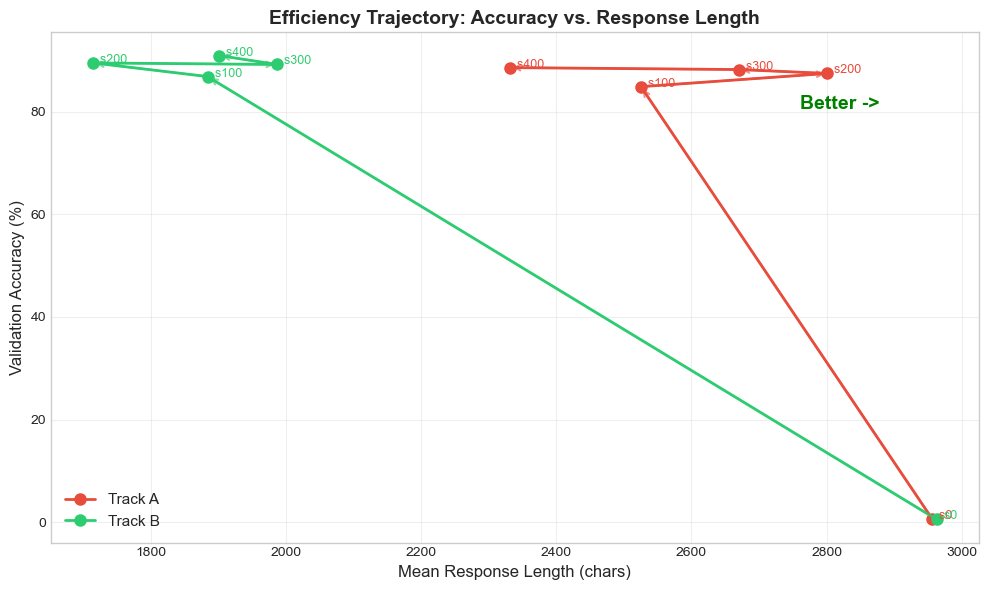


Efficiency data:
track  step  accuracy  mean_length
    A     0  0.006065  2956.769333
    A   100  0.848370  2525.334344
    A   200  0.874147  2801.370167
    A   300  0.881729  2669.795679
    A   400  0.885519  2331.063306
    B     0  0.006065  2962.768575
    B   100  0.868082  1883.817475
    B   200  0.894617  1714.561221
    B   300  0.891585  1986.964746
    B   400  0.909022  1900.487111


In [28]:
# Compute per-step aggregates
eff = df_questions.groupby(["track", "step"]).agg(
    accuracy=("is_correct", "mean"),
    mean_length=("response_length_mean", "mean"),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

for track, color in [("A", "#e74c3c"), ("B", "#2ecc71")]:
    d = eff[eff["track"] == track].sort_values("step")
    ax.plot(d["mean_length"], d["accuracy"] * 100, "o-", label=f"Track {track}", linewidth=2, markersize=8, color=color)
    # Add step annotations
    for _, row in d.iterrows():
        ax.annotate(f"  s{int(row['step'])}", 
                    xy=(row["mean_length"], row["accuracy"] * 100),
                    fontsize=9, color=color)
    # Draw arrows between steps
    for i in range(len(d) - 1):
        ax.annotate("", xy=(d.iloc[i+1]["mean_length"], d.iloc[i+1]["accuracy"] * 100),
                    xytext=(d.iloc[i]["mean_length"], d.iloc[i]["accuracy"] * 100),
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.5, alpha=0.6))

ax.set_xlabel("Mean Response Length (chars)", fontsize=12)
ax.set_ylabel("Validation Accuracy (%)", fontsize=12)
ax.set_title("Efficiency Trajectory: Accuracy vs. Response Length", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Ideal direction annotation
ax.annotate("Better ->", xy=(0.85, 0.85), xycoords="axes fraction",
            fontsize=14, color="green", fontweight="bold", ha="center")

plt.tight_layout()
plt.savefig("efficiency_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nEfficiency data:")
print(eff.to_string(index=False))

### Answer Position Over Time

This plot tracks where the `####` delimiter appears within correct answers. An earlier position (higher on the inverted y-axis) means the model is giving the final answer sooner, indicating more concise reasoning. Track B's line trending upward suggests it learned to place the answer earlier in the response.

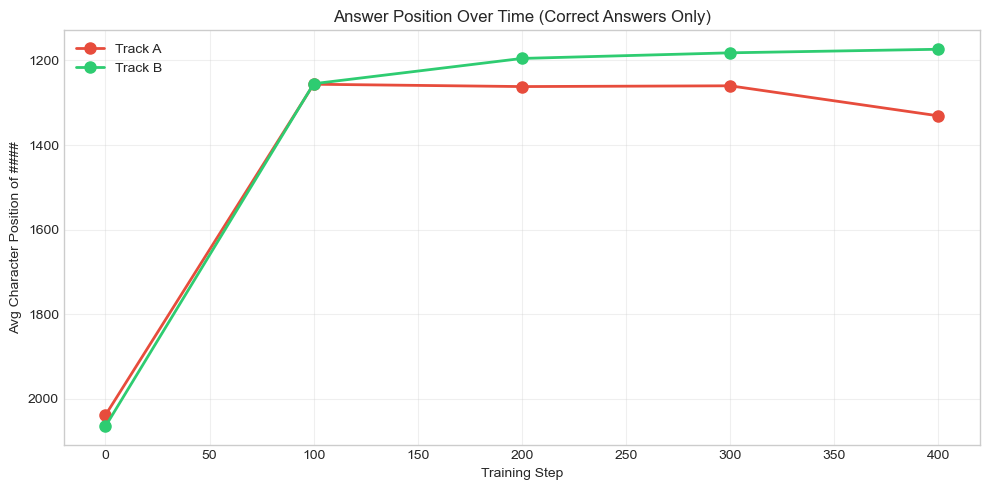


Answer position stats:
track  step  hash_position
    A     0    2038.761905
    A   100    1256.299074
    A   200    1261.805531
    A   300    1260.010009
    A   400    1331.016461
    B     0    2065.250000
    B   100    1255.064825
    B   200    1195.311049
    B   300    1182.009530
    B   400    1173.604251


In [29]:
import re

def find_hash_position(text):
    m = re.search(r"####", text)
    return m.start() if m else None

# Compute hash position for each rollout sample
df_rollouts["hash_position"] = df_rollouts["output_text"].apply(find_hash_position)

# Average position among correct answers that contain ####
pos_stats = df_rollouts[df_rollouts["is_correct"] & df_rollouts["has_hash"]].groupby(["track", "step"])["hash_position"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

for track, color in [("A", "#e74c3c"), ("B", "#2ecc71")]:
    d = pos_stats[pos_stats["track"] == track].sort_values("step")
    ax.plot(d["step"], d["hash_position"], "o-", label=f"Track {track}", linewidth=2, markersize=8, color=color)

ax.set_xlabel("Training Step")
ax.set_ylabel("Avg Character Position of ####")
ax.set_title("Answer Position Over Time (Correct Answers Only)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_yaxis()  # Earlier position = higher on chart = better

plt.tight_layout()
plt.savefig("answer_position.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAnswer position stats:")
print(pos_stats.to_string(index=False))